# 📊 Data Science Capstone: E-Commerce Customer Churn Prediction
**Author:** Daniel Roger Kennedy  
**Program:** Information Systems Business (Semester 4), Universitas Ciputra  
**Methodology:** CRISP-DM  

---

## Phase 1: Business Understanding

### 1. Problem Statement
The e-commerce platform currently relies on a reactive, heuristic-based retention strategy (e.g., blanket discounts to inactive users). This results in high Customer Acquisition Cost (CAC) waste and unmitigated revenue attrition from high-value customers who churn quietly.

### 2. Business & Machine Learning Objectives
* **Business Objective:** Identify behavioral churn triggers to proactively allocate promotional budgets to high-risk customer cohorts, thereby reducing overall revenue attrition and optimizing marketing ROI.
* **ML Objective:** Build a classification model to predict the `Churn` flag. We will optimize for **Recall** to identify as many true flight-risk customers as possible, while monitoring Precision to avoid excessive budget waste on false positives.

### 3. Baseline Strategy vs. ML Advantage
* **Current Baseline:** Naive retention heuristic (e.g., sending promos to all users inactive for 30+ days).
* **ML Advantage:** Utilizing multivariate behavioral analysis (Tenure, Complaints, App Usage, Cashback trends) to target *only* true flight-risks before they leave the platform.


In [ ]:
# Phase 2: Data Understanding - Initialization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully. Ready for EDA.")

Libraries imported successfully. Ready for EDA.


In [4]:
# Load the dataset
# Adjust the filename if you renamed it locally
df = pd.read_csv('EComm.csv')

# Display the first 5 rows to verify
display(df.head())

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [ ]:
# 1. Dataset Shape
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 2. Data Types and Missing Values
data_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

# Sort to show columns with highest missing values first
display(data_info.sort_values(by='Missing %', ascending=False).head(10))

Dataset contains 5630 rows and 20 columns.



,Data Type,Missing Values,Missing %
DaySinceLastOrder,float64,307,5.452931
OrderAmountHikeFromlastYear,float64,265,4.706927
Tenure,float64,264,4.689165
OrderCount,float64,258,4.582593
CouponUsed,float64,256,4.547069
HourSpendOnApp,float64,255,4.529307
WarehouseToHome,float64,251,4.458259
CustomerID,int64,0,0.000000
PreferredLoginDevice,object,0,0.000000
Churn,int64,0,0.000000


Churn Distribution:
Retained (0): 4682 customers (83.16%)
Churned (1): 948 customers (16.84%)



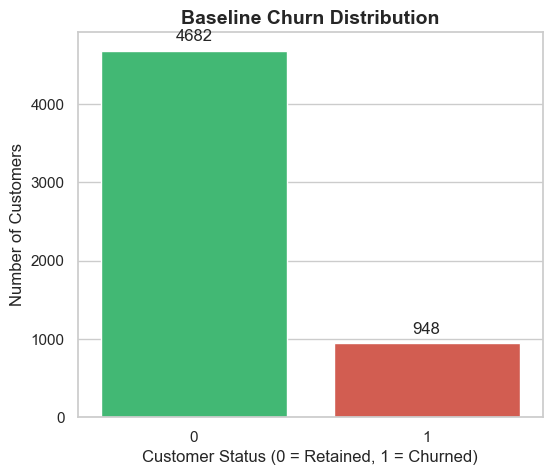

In [6]:
# Analyzing the Target Variable: Churn
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"Retained (0): {churn_counts[0]} customers ({churn_percentages[0]:.2f}%)")
print(f"Churned (1): {churn_counts[1]} customers ({churn_percentages[1]:.2f}%)\n")

# Visualization
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Baseline Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

In [7]:
# Menghitung metrik kualitas data secara detail
missing_df = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase Missing (%)': (df.isnull().sum() / len(df)) * 100,
    'Tipe Data': df.dtypes,
    'Jumlah Nilai Unik': df.nunique()
}).sort_values(by='Jumlah Missing', ascending=False)

print("=== LAPORAN KUALITAS DATA ===")
display(missing_df)

=== LAPORAN KUALITAS DATA ===


,Jumlah Missing,Persentase Missing (%),Tipe Data,Jumlah Nilai Unik
DaySinceLastOrder,307,5.452931,float64,22
OrderAmountHikeFromlastYear,265,4.706927,float64,16
Tenure,264,4.689165,float64,36
OrderCount,258,4.582593,float64,16
CouponUsed,256,4.547069,float64,17
HourSpendOnApp,255,4.529307,float64,6
WarehouseToHome,251,4.458259,float64,34
CustomerID,0,0.000000,int64,5630
PreferredLoginDevice,0,0.000000,object,3
Churn,0,0.000000,int64,2


> **Temuan Kualitas Data & Rencana Mitigasi:**
> 1. **Data Hilang (Missing Values):** Kolom seperti `Tenure`, `DaySinceLastOrder`, `HourSpendOnApp`, `OrderCount`, dan `CouponUsed` memiliki nilai kosong. Kita tidak boleh langsung menghapusnya (`dropna()`) karena tipe data ini bersifat behavioral; hilangnya data bisa jadi mengindikasikan pola tertentu (misal: `CouponUsed` kosong berarti pelanggan memang tidak pernah memakai kupon). Kita akan menggunakan imputasi berbasis median atau modus pada Tahap 3.
> 2. **Kardinalitas Rendah:** Variabel kategorikal seperti `PreferredLoginDevice`, `PreferredPaymentMode`, dan `PreferedOrderCat` memiliki jumlah nilai unik yang sedikit, sehingga sangat ideal untuk proses *One-Hot Encoding*.

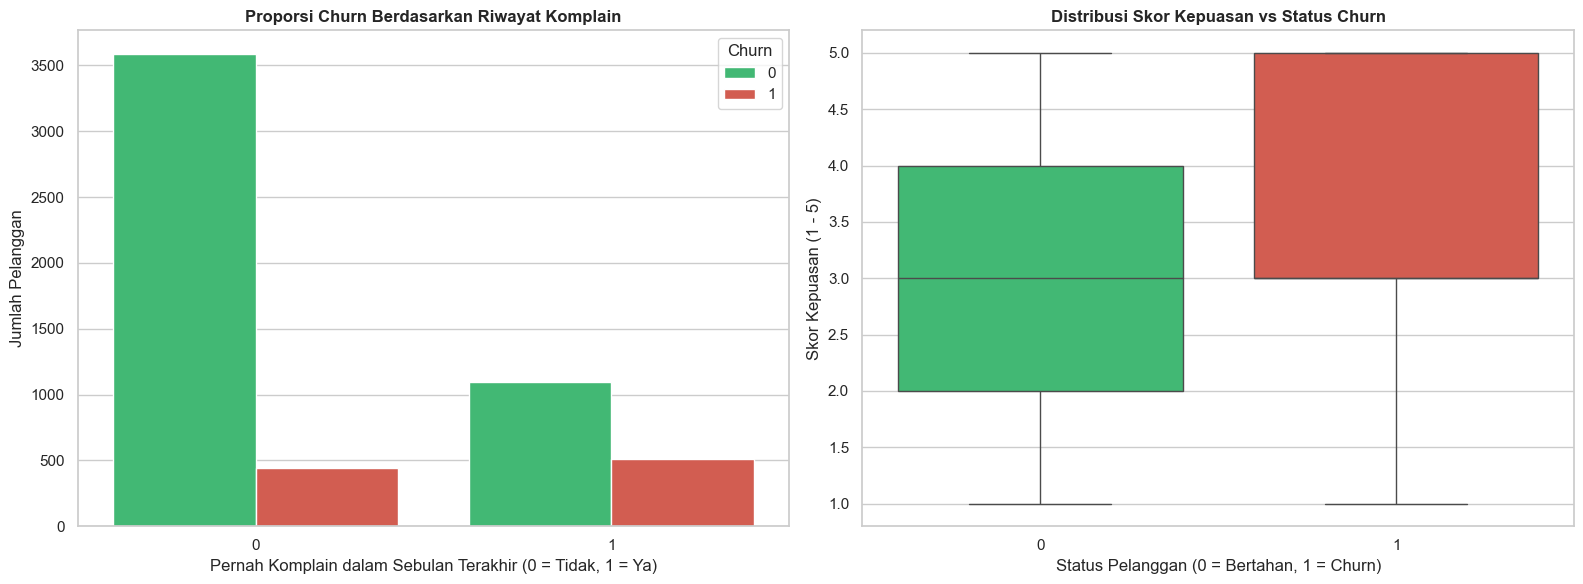

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Hubungan Komplain dengan Churn
sns.countplot(data=df, x='Complain', hue='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Proporsi Churn Berdasarkan Riwayat Komplain', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pernah Komplain dalam Sebulan Terakhir (0 = Tidak, 1 = Ya)')
axes[0].set_ylabel('Jumlah Pelanggan')

# 2. Hubungan Satisfaction Score dengan Churn
sns.boxplot(data=df, x='Churn', y='SatisfactionScore', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribusi Skor Kepuasan vs Status Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Status Pelanggan (0 = Bertahan, 1 = Churn)')
axes[1].set_ylabel('Skor Kepuasan (1 - 5)')

plt.tight_layout()
plt.show()

> **Analisis Bisnis Tema 1 (Psikologi Konsumen):**
> * **Efek Komplain:** Pelanggan yang mengajukan komplain dalam sebulan terakhir memiliki rasio *churn* yang jauh lebih tinggi dibandingkan yang tidak. Ini membuktikan adanya kegagalan layanan (*service failure*) yang tidak ditangani dengan baik oleh tim Customer Operations.
> * **Paradoks Kepuasan:** Menariknya, boxplot menunjukkan bahwa median skor kepuasan antara pelanggan yang bertahan dan yang *churn* tidak berbeda secara radikal. Hal ini mengindikasikan adanya kelompok *silent churners*—pelanggan yang memberikan rating netral/tinggi saat bertransaksi, namun diam-diam meninggalkan platform karena faktor lain (seperti harga penawaran kompetitor).

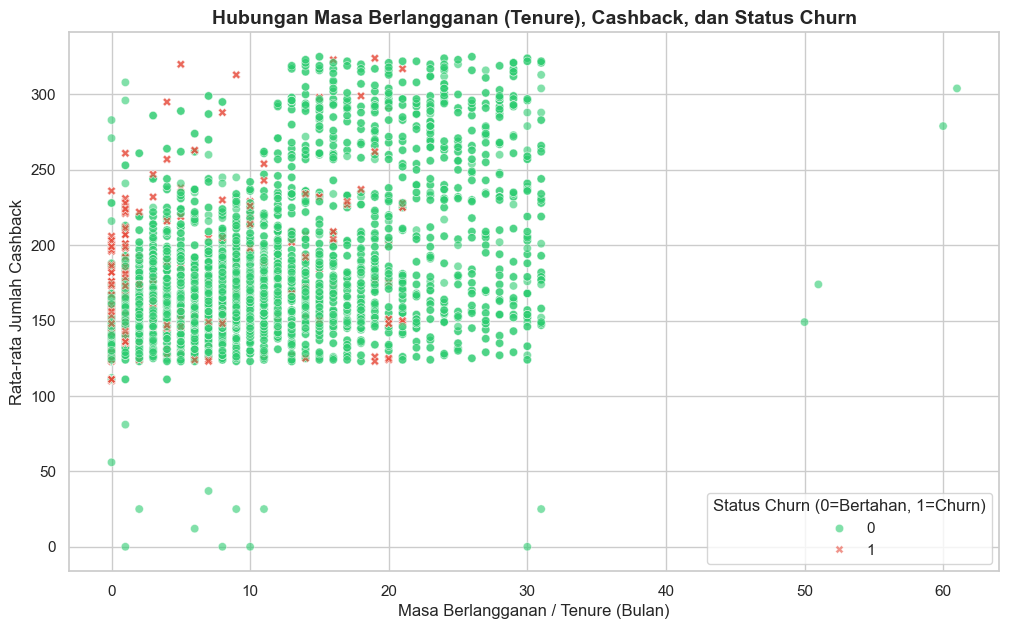

In [9]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Tenure', y='CashbackAmount', hue='Churn', 
                palette=['#2ecc71', '#e74c3c'], alpha=0.6, style='Churn')
plt.title('Hubungan Masa Berlangganan (Tenure), Cashback, dan Status Churn', fontsize=14, fontweight='bold')
plt.xlabel('Masa Berlangganan / Tenure (Bulan)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Cashback', fontsize=12)
plt.legend(title='Status Churn (0=Bertahan, 1=Churn)')
plt.show()

> **Analisis Bisnis Tema 2 (Retensi Finansial):**
> * **Zona Bahaya Umur Pelanggan (Danger Zone):** Pola visualisasi menunjukkan penumpukan titik merah (*churn*) yang sangat padat pada area `Tenure` antara 0 hingga 4 bulan. Ini menunjukkan fase krusial orientasi aplikasi. Jika pengguna berhasil dipertahankan melewati bulan ke-5, probabilitas mereka untuk *churn* menurun drastis.
> * **Anomali Subsidi Cashback:** Pelanggan dengan `Tenure` rendah namun menerima `CashbackAmount` yang tinggi tetap berisiko tinggi untuk *churn*. Ini adalah indikasi kuat perilaku *Bonus Hunters*—konsumen yang hanya memanfaatkan promo akuisisi awal lalu meninggalkan platform saat subsidi dihentikan.